In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical, plot_model
import os

import warnings
warnings.filterwarnings("ignore")


In [4]:
data = []
result = []


for r, d, f in os.walk(r"D:\\stroke.csv\\stroke_cropped\\CROPPED\\TRAIN_CROP\\NORMAL"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0   # 🔥 normalization

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([0, 1]) 

In [5]:
for r, d, f in os.walk(r"D:\\stroke.csv\\stroke_cropped\\CROPPED\\TRAIN_CROP\\STROKE"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([1, 0])

In [6]:
data = np.array(data)
result = np.array(result)

print("Data shape:", data.shape)      
print("Result shape:", result.shape)

Data shape: (1473, 128, 128, 3)
Result shape: (1473, 2)


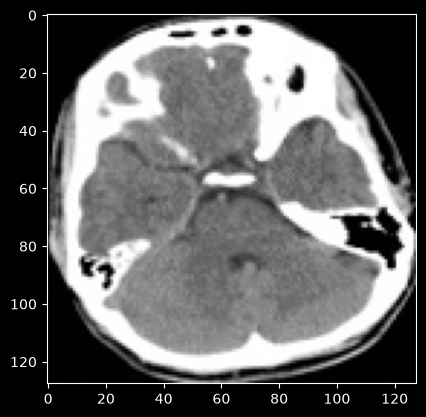

In [33]:
plt.imshow(data[55])

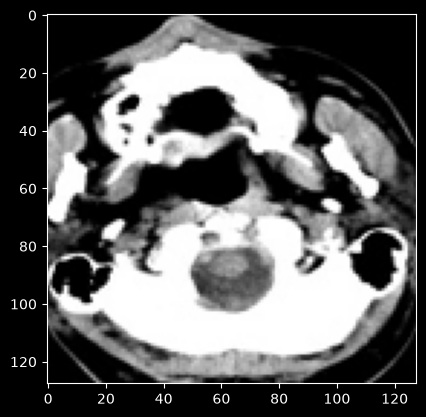

In [34]:
plt.imshow(data[870])

In [8]:
x_train, x_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle=True, random_state=42)

In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None


In [10]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [11]:
x_train.shape

(1178, 128, 128, 3)

In [12]:
y_train.shape

(1178, 2)

In [42]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    verbose=1,
    validation_data=(x_test, y_test))

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.8710 - loss: 0.2408 - val_accuracy: 0.6068 - val_loss: 3.5871
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8625 - loss: 0.2545 - val_accuracy: 0.6169 - val_loss: 3.2797
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.8803 - loss: 0.2419 - val_accuracy: 0.6102 - val_loss: 3.4156
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.8701 - loss: 0.2486 - val_accuracy: 0.6203 - val_loss: 4.4102
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8998 - loss: 0.2086 - val_accuracy: 0.6102 - val_loss: 4.5051
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.8854 - loss: 0.2210 - val_accuracy: 0.6102 - val_loss: 5.1260
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.9092 - loss: 0.1926 - val_accuracy: 0.6237 - val_loss: 4.5950
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.9032 - loss: 0.1880 - val_accuracy: 0.6441 - val_loss:

In [43]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - accuracy: 0.5356 - loss: 1.7926

Test accuracy: 53.6%


In [14]:
from PIL import Image

img_path = r"D:\stroke.csv\stroke_cropped\CROPPED\TEST_CROP\STROKE\138.jpg"
img = Image.open(img_path)
img = img.resize((128,128))
img = np.array(img) / 255.0   # 🔥 same preprocessing

img = np.expand_dims(img, axis=0)  # shape (1,128,128,3)

prediction = model.predict(img)
pred_class = np.argmax(prediction)

if pred_class == 0:
    print("Prediction: STROKE")
else:
    print("Prediction:  NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction:  NORMAL
